# Ques 1

In [87]:
def get_length(arr):
    count = 0
    for _ in arr:
        count += 1
    return count

def abs_value(x):
    if x < 0:
        return -x
    return x

def max_value(a, b):
    if a > b:
        return a
    return b

def int_floor(x):
    result = 0
    if x >= 0:
        while (result + 1) <= x:
            result += 1
    else:
        while result > x:
            result -= 1
    return result

def create_1d_array(size, fill_value=0.0):
    arr = []
    i = 0
    while i < size:
        arr.append(fill_value)
        i += 1
    return arr

def create_2d_array(rows, cols, fill_value=0.0):
    matrix = []
    i = 0
    while i < rows:
        matrix.append(create_1d_array(cols, fill_value))
        i += 1
    return matrix

def slice_array(arr, start_idx, end_idx):
    result = []
    i = start_idx
    while i <= end_idx:
        result.append(arr[i])
        i += 1
    return result

In [88]:
def compute_lagrange_basis(X_data, k, x_eval):
    n = get_length(X_data) - 1
    L_k = 1.0
    for j in range(0, n + 1):
        if j != k:
            L_k = L_k * (x_eval - X_data[j]) / (X_data[k] - X_data[j])
    return L_k

def lagrange_interpolation(X_data, Y_data, x_eval):
    n = get_length(X_data) - 1
    y_eval = 0.0
    for k in range(0, n + 1):
        L_k = compute_lagrange_basis(X_data, k, x_eval)
        y_eval = y_eval + Y_data[k] * L_k
    return y_eval

In [89]:
def build_newton_table(X_data, Y_data):
    N = get_length(X_data)
    F = create_2d_array(N, N, 0.0)
    for i in range(0, N):
        F[i][0] = Y_data[i]
    for j in range(1, N):
        for i in range(0, N - j):
            F[i][j] = (F[i + 1][j - 1] - F[i][j - 1]) / (X_data[i + j] - X_data[i])
    Coef = create_1d_array(N, 0.0)
    for k in range(0, N):
        Coef[k] = F[0][k]
    return Coef

def evaluate_newton_poly(Coef, X_data, x_eval):
    N = get_length(Coef)
    result = Coef[N - 1]
    for k in range(N - 2, -1, -1):
        result = Coef[k] + (x_eval - X_data[k]) * result
    return result

In [90]:
T_data = [30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0]
rA_data = [0.82, 1.15, 1.62, 2.20, 2.85, 3.50, 4.10, 4.60, 5.00, 5.30, 5.45]
rA_target = 4.20

# Part A
grid_points = 500
T_grid = [30.0 + i * (80.0 - 30.0) / (grid_points - 1) for i in range(grid_points)]
P10_vals = [lagrange_interpolation(T_data, rA_data, t) for t in T_grid]

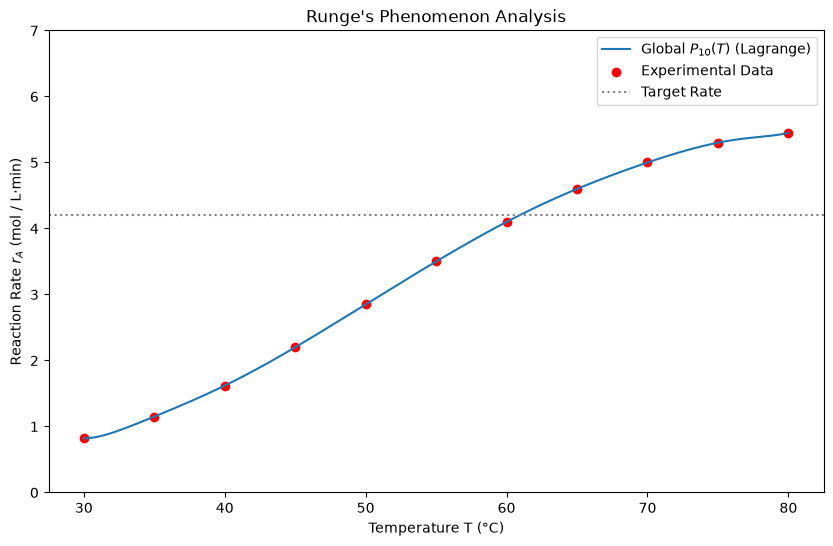

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(T_grid, P10_vals, label="Global $P_{10}(T)$ (Lagrange)")
plt.scatter(T_data, rA_data, color='red', label="Experimental Data")
plt.axhline(rA_target, color='gray', linestyle=':', label="Target Rate")
plt.ylim(0, 7)
plt.title("Runge's Phenomenon Analysis")
plt.xlabel("Temperature T (°C)")
plt.ylabel("Reaction Rate $r_A$ (mol / L·min)")
plt.legend()
plt.show()

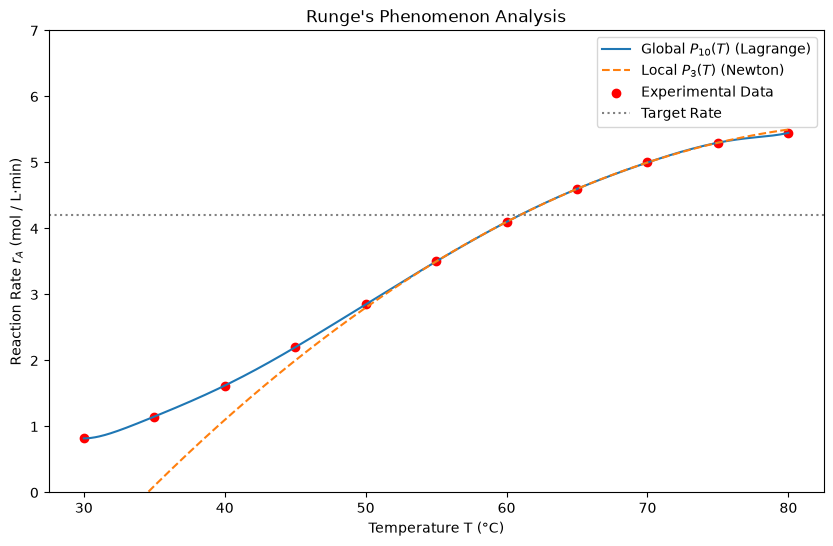

In [92]:

def find_closest_index(X_data, x_eval):
    N = get_length(X_data)
    min_dist = float('inf')
    closest_idx = 0
    for i in range(0, N):
        dist = abs_value(X_data[i] - x_eval)
        if dist < min_dist:
            min_dist = dist
            closest_idx = i
    return closest_idx

def select_local_stencil(X_data, Y_data, closest_idx, m):
    N = get_length(X_data)
    start_idx = max_value(0, closest_idx - int_floor(m / 2))
    end_idx = start_idx + m
    if end_idx >= N:
        end_idx = N - 1
        start_idx = max_value(0, end_idx - m)
    X_local = slice_array(X_data, start_idx, end_idx)
    Y_local = slice_array(Y_data, start_idx, end_idx)
    return X_local, Y_local

def local_newton_interpolation(X_data, Y_data, x_eval, m=3):
    closest_idx = find_closest_index(X_data, x_eval)
    X_local, Y_local = select_local_stencil(X_data, Y_data, closest_idx, m)
    Coef_local = build_newton_table(X_local, Y_local)
    y_eval = evaluate_newton_poly(Coef_local, X_local, x_eval)
    return y_eval

# Select 4 nodes for P3 near target rate 4.20 (which is close to T=61)
# Nodes: 55, 60, 65, 70
T_local = T_data[5:9] 
rA_local = rA_data[5:9]

Coef_local = build_newton_table(T_local, rA_local)
P3_vals = [evaluate_newton_poly(Coef_local, T_local, t) for t in T_grid]

plt.figure(figsize=(10, 6))
plt.plot(T_grid, P10_vals, label="Global $P_{10}(T)$ (Lagrange)")
plt.plot(T_grid, P3_vals, label="Local $P_3(T)$ (Newton)", linestyle='--')
plt.scatter(T_data, rA_data, color='red', label="Experimental Data")
plt.axhline(rA_target, color='gray', linestyle=':', label="Target Rate")
plt.ylim(0, 7)
plt.title("Runge's Phenomenon Analysis")
plt.xlabel("Temperature T (°C)")
plt.ylabel("Reaction Rate $r_A$ (mol / L·min)")
plt.legend()
plt.show()

## Part B

In [93]:
def g_P10(T):
    return lagrange_interpolation(T_data, rA_data, T) - rA_target

def g_prime_P10(T, h=1e-5):
    return (g_P10(T + h) - g_P10(T - h)) / (2 * h)

def g_P3(T):
    return evaluate_newton_poly(Coef_local, T_local, T) - rA_target

def g_prime_P3(T):
    a0, a1, a2, a3 = Coef_local
    t0, t1, t2, t3 = T_local
    term1 = a1
    term2 = a2 * ((T - t1) + (T - t0))
    term3 = a3 * ((T - t1)*(T - t2) + (T - t0)*(T - t2) + (T - t0)*(T - t1))
    return term1 + term2 + term3

def newton_raphson_guarded(T0, g_func, g_prime_func, max_iter=50, tol=1e-6):
    T_k = T0
    for i in range(max_iter):
        g_val = g_func(T_k)
        if abs_value(g_val) < tol:
            return T_k, i
        g_prime_val = g_prime_func(T_k)
        T_next = T_k - g_val / g_prime_val
        if T_next < 30.0:
            T_next = 30.0
        elif T_next > 80.0:
            T_next = 80.0
        if abs_value(T_next - T_k) < tol:
            return T_next, i
        T_k = T_next
    return T_k, max_iter

In [94]:
# Run without guard from 31.0 for P10
print("Testing Newton-Raphson without guard for P10 from T0 = 31.0:")
T_k = 31.0
for i in range(20):
    g_val = g_P10(T_k)
    g_prime_val = g_prime_P10(T_k)
    T_next = T_k - g_val / g_prime_val
    print(f"Iter {i+1}: T = {T_next:.4f}")
    if abs_value(T_next - T_k) < 1e-6:
        break
    T_k = T_next
print("Analysis: Without bounds, the algorithm often diverges or oscillates wildly due to Runge's phenomenon near boundaries.\n")

Testing Newton-Raphson without guard for P10 from T0 = 31.0:
Iter 1: T = 104.2704
Iter 2: T = 99.9622
Iter 3: T = 96.1555
Iter 4: T = 92.8015
Iter 5: T = 89.8438
Iter 6: T = 87.1967
Iter 7: T = 84.6788
Iter 8: T = 81.7147
Iter 9: T = 73.7850
Iter 10: T = 54.0519
Iter 11: T = 60.4447
Iter 12: T = 60.9106
Iter 13: T = 60.9151
Iter 14: T = 60.9151
Analysis: Without bounds, the algorithm often diverges or oscillates wildly due to Runge's phenomenon near boundaries.



In [95]:
# Run safe solver from T0 = 58.0
T_star_10, iters_10 = newton_raphson_guarded(58.0, g_P10, g_prime_P10)
T_star_3, iters_3 = newton_raphson_guarded(58.0, g_P3, g_prime_P3)

print(f"Safe Solver Converged Results (T0 = 58.0):")
print(f"Global P10: T* = {T_star_10:.4f} °C (Converged in {iters_10} iterations)")
print(f"Local P3: T* = {T_star_3:.4f} °C (Converged in {iters_3} iterations)")

Safe Solver Converged Results (T0 = 58.0):
Global P10: T* = 60.9151 °C (Converged in 3 iterations)
Local P3: T* = 60.9246 °C (Converged in 3 iterations)


# Ques 3

In [96]:
# --- Raw sampling data -------------------------------------------------------
z_data = [0.0, 1.2, 2.8, 4.0]
C_data = [250.0, 110.0, 42.0, 15.0]


def build_newton_table(x, y):
    """
    Builds the Newton divided-difference table.
    Returns the coefficient array a[0..n] = F[0][0..n] (the top row),
    i.e. the coefficients of the Newton nested-form polynomial.
    """
    n = len(y)
    F = [[0.0] * n for _ in range(n)]
    for i in range(n):
        F[i][0] = y[i]

    for j in range(1, n):
        for i in range(n - j):
            F[i][j] = (F[i + 1][j - 1] - F[i][j - 1]) / (x[i + j] - x[i])

    return [F[0][k] for k in range(n)], F


coef, F_table = build_newton_table(z_data, C_data)


In [97]:
print(f"{'z_i':>8} | {'C[z_i]':>12} | {'1st DD':>12} | {'2nd DD':>12} | {'3rd DD':>12}")
for i in range(len(z_data)):
    row = [f"{z_data[i]:8.2f}", f"{F_table[i][0]:12.6f}"]
    for j in range(1, len(z_data) - i):
        row.append(f"{F_table[i][j]:12.6f}")
    print(" | ".join(row))

     z_i |       C[z_i] |       1st DD |       2nd DD |       3rd DD
    0.00 |   250.000000 |  -116.666667 |    26.488095 |    -4.836310
    1.20 |   110.000000 |   -42.500000 |     7.142857
    2.80 |    42.000000 |   -22.500000
    4.00 |    15.000000


In [98]:
print("\nNewton coefficients a0, a1, a2, a3:")
for k, a in enumerate(coef):
    print(f"  a{k} = {a:.6f}")


Newton coefficients a0, a1, a2, a3:
  a0 = 250.000000
  a1 = -116.666667
  a2 = 26.488095
  a3 = -4.836310


In [99]:
print("\nInterpolating polynomial in NESTED (Newton / Horner) form:")
print(f"  C(z) = {coef[0]:.6f}")
print(f"       + (z - {z_data[0]:.1f}) * [ {coef[1]:.6f}")
print(f"       + (z - {z_data[1]:.1f}) * [ {coef[2]:.6f}")
print(f"       + (z - {z_data[2]:.1f}) * ( {coef[3]:.6f} ) ] ]")


Interpolating polynomial in NESTED (Newton / Horner) form:
  C(z) = 250.000000
       + (z - 0.0) * [ -116.666667
       + (z - 1.2) * [ 26.488095
       + (z - 2.8) * ( -4.836310 ) ] ]


In [100]:
def C_and_Cprime(z, coef, x_data):
    n = len(coef)
    C = coef[0]
    Cp = 0.0
    prod = 1.0
    deriv_prod = 0.0

    for k in range(1, n):
        factor = z - x_data[k - 1]
        new_deriv_prod = prod + factor * deriv_prod   # P_k'  (uses OLD P_{k-1}, P_{k-1}')
        new_prod = prod * factor                       # P_k
        prod, deriv_prod = new_prod, new_deriv_prod
        C += coef[k] * prod
        Cp += coef[k] * deriv_prod

    return C, Cp

In [101]:
z_mid = [0.6, 2.0, 3.4]
vals = {}
for zm in z_mid:
    Cval, Cpval = C_and_Cprime(zm, coef, z_data)
    vals[zm] = (Cval, Cpval)
    print(f"  z = {zm:>4} :  C(z) = {Cval:10.5f}   C'(z) = {Cpval:10.5f}")

C1, Cp1 = vals[0.6]
C2, Cp2 = vals[2.0]
C3, Cp3 = vals[3.4]

# Governing system A k = b  (k = [k1, k2, k3, k4]^T)
A = [
    [C1,  Cp1, 0.0, 0.0],
    [0.0, C2,  Cp2, 0.0],
    [0.0, 0.0, C3,  Cp3],
    [1.0, 1.0, 1.0, 1.0],
]
b = [180.0, 65.0, 22.0, 1.0]

print("\nMatrix A:")
for row in A:
    print("  [" + "  ".join(f"{v:12.5f}" for v in row) + "]")
print("Vector b:", b)


  z =  0.6 :  C(z) =  166.63393   C'(z) = -114.92560
  z =  2.0 :  C(z) =   65.23810   C'(z) =  -39.40476
  z =  3.4 :  C(z) =   29.75893   C'(z) =  -20.75893

Matrix A:
  [   166.63393    -114.92560       0.00000       0.00000]
  [     0.00000      65.23810     -39.40476       0.00000]
  [     0.00000       0.00000      29.75893     -20.75893]
  [     1.00000       1.00000       1.00000       1.00000]
Vector b: [180.0, 65.0, 22.0, 1.0]


In [102]:
def lu_decompose_partial_pivot(A):
    """
    Doolittle LU decomposition with partial (row) pivoting.
    Factors  P A = L U.

    Returns:
        L : lower-triangular matrix with unit diagonal
        U : upper-triangular matrix
        P : permutation vector, where P[i] = original row index now in
            position i (so P A means A rows are reordered as A[P[0]], A[P[1]], ...)
    """
    n = len(A)
    # Work on a copy
    U = [row[:] for row in A]
    L = [[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]
    P = list(range(n))

    for k in range(n):
        # --- Partial pivoting: find row with largest |U[i][k]| for i >= k ---
        pivot_row = max(range(k, n), key=lambda i: abs(U[i][k]))
        if pivot_row != k:
            U[k], U[pivot_row] = U[pivot_row], U[k]
            P[k], P[pivot_row] = P[pivot_row], P[k]
            # swap already-computed multipliers in L (columns < k)
            for j in range(k):
                L[k][j], L[pivot_row][j] = L[pivot_row][j], L[k][j]

        if abs(U[k][k]) < 1e-14:
            raise ZeroDivisionError("Matrix is singular (zero pivot) even after pivoting.")

        # --- Elimination ---
        for i in range(k + 1, n):
            factor = U[i][k] / U[k][k]
            L[i][k] = factor
            for j in range(k, n):
                U[i][j] -= factor * U[k][j]

    return L, U, P


def lu_solve(L, U, P, b):
    """
    Solves A x = b given the P, L, U factors from lu_decompose_partial_pivot,
    via forward substitution (L y = P b) then back substitution (U x = y).
    """
    n = len(b)
    b_permuted = [b[P[i]] for i in range(n)]

    # Forward substitution: L y = Pb
    y = [0.0] * n
    for i in range(n):
        s = b_permuted[i]
        for j in range(i):
            s -= L[i][j] * y[j]
        y[i] = s / L[i][i]

    # Back substitution: U x = y
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = y[i]
        for j in range(i + 1, n):
            s -= U[i][j] * x[j]
        x[i] = s / U[i][i]

    return x



In [103]:
L, U, P = lu_decompose_partial_pivot(A)

print("\nPermutation P (row order after pivoting):", P)
print("\nL =")
for row in L:
    print("  [" + "  ".join(f"{v:10.5f}" for v in row) + "]")
print("U =")
for row in U:
    print("  [" + "  ".join(f"{v:10.5f}" for v in row) + "]")


Permutation P (row order after pivoting): [0, 1, 2, 3]

L =
  [   1.00000     0.00000     0.00000     0.00000]
  [   0.00000     1.00000     0.00000     0.00000]
  [   0.00000     0.00000     1.00000     0.00000]
  [   0.00600     0.02590     0.06790     1.00000]
U =
  [ 166.63393  -114.92560     0.00000     0.00000]
  [   0.00000    65.23810   -39.40476     0.00000]
  [   0.00000     0.00000    29.75893   -20.75893]
  [   0.00000     0.00000     0.00000     2.40951]


In [104]:
k_solution = lu_solve(L, U, P, b)

print("\nSolution vector k = [k1, k2, k3, k4]:")
for i, kv in enumerate(k_solution, start=1):
    print(f"  k{i} = {kv:.6f}")

# --- Verification: residual A k - b -----------------------------------------
residual = []
for i in range(4):
    s = sum(A[i][j] * k_solution[j] for j in range(4))
    residual.append(s - b[i])
print("\nResidual (A k - b), should be ~0:", [f"{r:.2e}" for r in residual])


Solution vector k = [k1, k2, k3, k4]:
  k1 = 1.682485
  k2 = 0.873253
  k3 = -0.203798
  k4 = -1.351940

Residual (A k - b), should be ~0: ['0.00e+00', '0.00e+00', '0.00e+00', '0.00e+00']


In [105]:
def lagrange_rebuild_flop_count(x_nodes):
    n = len(x_nodes)
    flops = 0
    weights = [0.0] * n
    for k in range(n):
        prod = 1.0
        for j in range(n):
            if j != k:
                diff = x_nodes[k] - x_nodes[j]   # 1 subtraction
                flops += 1
                prod *= diff                     # 1 multiplication
                flops += 1
        weights[k] = 1.0 / prod                  # 1 division
        flops += 1
    return flops


def newton_append_flop_count(F_old, x_old, x_new, y_new):
    n_old = len(x_old)
    flops = 0

    diag = [y_new]  # F[n_old][0], no arithmetic needed to store it
    for j in range(1, n_old + 1):
        left_new = diag[j - 1]                    # previous entry on this same new diagonal
        right_existing = F_old[n_old - j][j - 1]   # pre-existing, already-computed entry
        numerator = left_new - right_existing      # 1 subtraction
        denominator = x_new - x_old[n_old - j]     # 1 subtraction
        flops += 2
        new_val = numerator / denominator          # 1 division
        flops += 1
        diag.append(new_val)

    return flops  # = 3 * n_old  ->  O(n)

In [106]:
# --- Run the micro-benchmark for a range of dataset sizes -------------------
sizes = list(range(4, 41, 2))
lagrange_flops = []
newton_flops = []

for n in sizes:
    x_nodes = [float(i) for i in range(n)]  # arbitrary increasing nodes
    y_nodes = [float(i * i) for i in range(n)]  # arbitrary values

    # Lagrange: rebuild ALL n weights from scratch (as required on update)
    lagrange_flops.append(lagrange_rebuild_flop_count(x_nodes))

    # Newton: build table for first (n-1) points, then append the n-th point
    x_old, y_old = x_nodes[:-1], y_nodes[:-1]
    _, F_old = build_newton_table(x_old, y_old)
    newton_flops.append(newton_append_flop_count(F_old, x_old, x_nodes[-1], y_nodes[-1]))

print(f"{'n (points)':>12} | {'Lagrange FLOPs (O(n^2))':>26} | {'Newton append FLOPs (O(n))':>28}")
for n, lf, nf in zip(sizes, lagrange_flops, newton_flops):
    print(f"{n:>12} | {lf:>26} | {nf:>28}")


  n (points) |    Lagrange FLOPs (O(n^2)) |   Newton append FLOPs (O(n))
           4 |                         28 |                            9
           6 |                         66 |                           15
           8 |                        120 |                           21
          10 |                        190 |                           27
          12 |                        276 |                           33
          14 |                        378 |                           39
          16 |                        496 |                           45
          18 |                        630 |                           51
          20 |                        780 |                           57
          22 |                        946 |                           63
          24 |                       1128 |                           69
          26 |                       1326 |                           75
          28 |                       1540 |        


FLOP comparison plot saved.


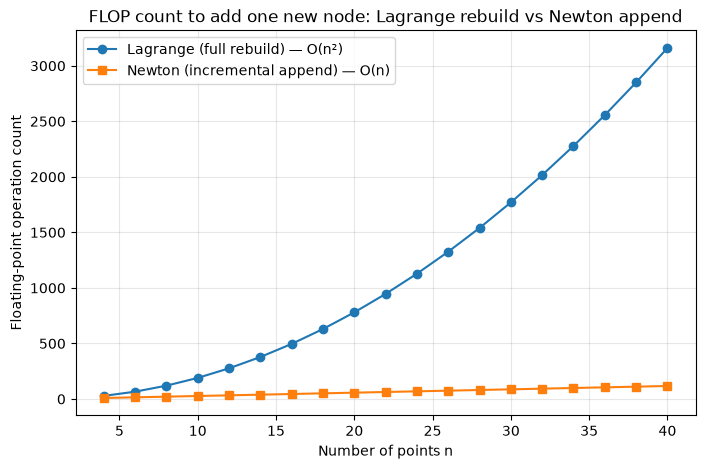

In [ ]:
# --- Plot: operation counts vs n, log-scale to show O(n) vs O(n^2) ---------
plt.figure(figsize=(8, 5))
plt.plot(sizes, lagrange_flops, 'o-', label="Lagrange (full rebuild) — O(n²)")
plt.plot(sizes, newton_flops, 's-', label="Newton (incremental append) — O(n)")
plt.xlabel("Number of points n")
plt.ylabel("Floating-point operation count")
plt.title("FLOP count to add one new node: Lagrange rebuild vs Newton append")
plt.legend()
plt.grid(alpha=0.3)
print("\nFLOP comparison plot saved.")

Log-log FLOP comparison plot saved.


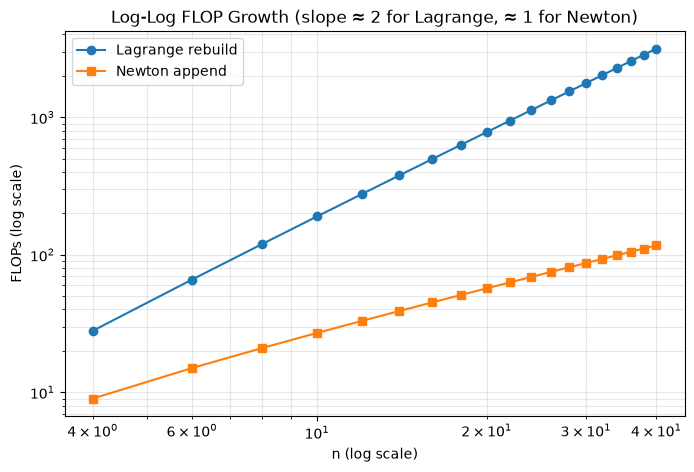

In [108]:
# Log-log plot to explicitly confirm the polynomial order (slope = exponent)
plt.figure(figsize=(8, 5))
plt.loglog(sizes, lagrange_flops, 'o-', label="Lagrange rebuild")
plt.loglog(sizes, newton_flops, 's-', label="Newton append")
plt.xlabel("n (log scale)")
plt.ylabel("FLOPs (log scale)")
plt.title("Log-Log FLOP Growth (slope ≈ 2 for Lagrange, ≈ 1 for Newton)")
plt.legend()
plt.grid(alpha=0.3, which="both")
print("Log-log FLOP comparison plot saved.")

In [109]:
# Empirically estimate the growth-rate exponent from the collected data
import math
def estimate_exponent(sizes, flops):
    x1, x2 = sizes[len(sizes)//2], sizes[-1]
    y1, y2 = flops[len(sizes)//2], flops[-1]
    return (math.log(y2) - math.log(y1)) / (math.log(x2) - math.log(x1))

print(f"\nEmpirical growth exponent (Lagrange): {estimate_exponent(sizes, lagrange_flops):.3f}  (expect ~2)")
print(f"Empirical growth exponent (Newton)  : {estimate_exponent(sizes, newton_flops):.3f}  (expect ~1)")


Empirical growth exponent (Lagrange): 2.017  (expect ~2)
Empirical growth exponent (Newton)  : 1.035  (expect ~1)
